<a href="https://colab.research.google.com/github/david181222/Parcial4/blob/main/SIMULACRO5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# Librerias base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from itertools import product
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.datasets import fashion_mnist

# Reproducibilidad
SEMILLA = 42
np.random.seed(SEMILLA)
tf.keras.utils.set_random_seed(SEMILLA)

# Configuracion visual
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

print('TensorFlow:', tf.__version__)
print('NumPy:', np.__version__)

TensorFlow: 2.19.0
NumPy: 2.0.2


In [11]:
# Cargar dataset Fashion-MNIST
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

CLASS_NAMES = [
    'Camiseta/Top', 'Pantalon', 'Sueter', 'Vestido', 'Abrigo',
    'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botin'
 ]

print(f'Datos de entrenamiento: {X_train_full.shape}')
print(f'Etiquetas de entrenamiento: {y_train_full.shape}')
print(f'Datos de prueba: {X_test.shape}')
print(f'Etiquetas de prueba: {y_test.shape}')

print('\nRango de pixeles original:')
print('Train ->', X_train_full.min(), X_train_full.max())
print('Test  ->', X_test.min(), X_test.max())

Datos de entrenamiento: (60000, 28, 28)
Etiquetas de entrenamiento: (60000,)
Datos de prueba: (10000, 28, 28)
Etiquetas de prueba: (10000,)

Rango de pixeles original:
Train -> 0 255
Test  -> 0 255


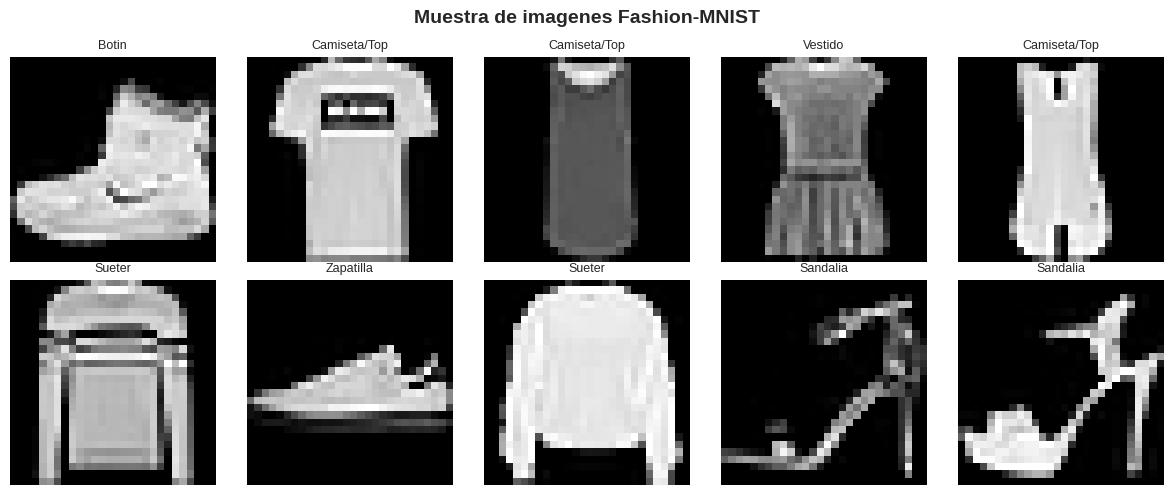

In [12]:
# Visualizacion rapida de ejemplos
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Muestra de imagenes Fashion-MNIST', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_full[i], cmap='gray')
    ax.set_title(CLASS_NAMES[y_train_full[i]], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# Normalizacion a [0, 1]
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Agregar canal: (28, 28) -> (28, 28, 1)
X_train_full = np.expand_dims(X_train_full, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# Separacion train/val reproducible
val_size = 10000
indices = np.arange(len(X_train_full))
np.random.shuffle(indices)

val_idx = indices[:val_size]
train_idx = indices[val_size:]

X_val = X_train_full[val_idx]
y_val = y_train_full[val_idx]
X_train = X_train_full[train_idx]
y_train = y_train_full[train_idx]

print('Shapes finales:')
print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('X_val:  ', X_val.shape, '| y_val:  ', y_val.shape)
print('X_test: ', X_test.shape, '| y_test: ', y_test.shape)

Shapes finales:
X_train: (50000, 28, 28, 1) | y_train: (50000,)
X_val:   (10000, 28, 28, 1) | y_val:   (10000,)
X_test:  (10000, 28, 28, 1) | y_test:  (10000,)


In [14]:
def build_cnn_base(learning_rate=0.001):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_callbacks():
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=0
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=0
    )

    return [reduce_lr, early_stop]


def run_experiment(initial_lr, batch_size, max_epochs):
    # Reinicia la semilla para reducir ruido aleatorio entre corridas.
    tf.keras.utils.set_random_seed(SEMILLA)

    model = build_cnn_base(learning_rate=initial_lr)
    callbacks = build_callbacks()

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0
    )

    real_epochs = len(history.history['loss'])
    final_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))

    train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)

    result = {
        'initial_lr': float(initial_lr),
        'batch_size': int(batch_size),
        'max_epochs': int(max_epochs),
        'real_epochs': int(real_epochs),
        'final_lr': float(final_lr),
        'train_accuracy': float(train_accuracy),
        'val_accuracy': float(val_accuracy),
        'train_loss': float(train_loss),
        'val_loss': float(val_loss),
        'lr_reduced': bool(final_lr < (initial_lr - 1e-12)),
        'early_stopped': bool(real_epochs < max_epochs)
    }

    return result, history

In [15]:
# Grid de hiperparametros
lr_values = [0.001, 0.005, 0.01]
batch_values = [64, 128]
epoch_values = [20, 30]

experiment_grid = list(product(lr_values, batch_values, epoch_values))
print(f'Total de experimentos: {len(experiment_grid)}')

# Ejecutar experimentos
results = []
all_histories = {}

for i, (lr, batch_size, max_epochs) in enumerate(experiment_grid, start=1):
    print(f'[{i:02d}/12] Entrenando -> LR={lr}, Batch={batch_size}, Epochs={max_epochs}')
    result, history = run_experiment(
        initial_lr=lr,
        batch_size=batch_size,
        max_epochs=max_epochs
    )
    result['experiment_id'] = i
    results.append(result)
    all_histories[i] = history

results_df = pd.DataFrame(results)
results_df = results_df[[
    'experiment_id', 'initial_lr', 'batch_size', 'max_epochs', 'real_epochs',
    'final_lr', 'val_accuracy', 'train_accuracy', 'val_loss', 'train_loss',
    'lr_reduced', 'early_stopped'
]].sort_values('experiment_id').reset_index(drop=True)

print('\nTabla final de resultados (12 experimentos):')
display(results_df)

Total de experimentos: 12
[01/12] Entrenando -> LR=0.001, Batch=64, Epochs=20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[02/12] Entrenando -> LR=0.001, Batch=64, Epochs=30
[03/12] Entrenando -> LR=0.001, Batch=128, Epochs=20
[04/12] Entrenando -> LR=0.001, Batch=128, Epochs=30
[05/12] Entrenando -> LR=0.005, Batch=64, Epochs=20
[06/12] Entrenando -> LR=0.005, Batch=64, Epochs=30
[07/12] Entrenando -> LR=0.005, Batch=128, Epochs=20
[08/12] Entrenando -> LR=0.005, Batch=128, Epochs=30
[09/12] Entrenando -> LR=0.01, Batch=64, Epochs=20
[10/12] Entrenando -> LR=0.01, Batch=64, Epochs=30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[11/12] Entrenando -> LR=0.01, Batch=128, Epochs=20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[12/12] Entrenando -> LR=0.01, Batch=128, Epochs=30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Tabla final de resultados (12 experimentos):


,experiment_id,initial_lr,batch_size,max_epochs,real_epochs,final_lr,val_accuracy,train_accuracy,val_loss,train_loss,lr_reduced,early_stopped
0,1,0.001,64,20,15,0.000500,0.9135,0.93998,0.237418,0.161281,True,True
1,2,0.001,64,30,15,0.000500,0.9118,0.93872,0.238141,0.163704,True,True
2,3,0.001,128,20,20,0.000500,0.9168,0.95088,0.235652,0.132778,True,False
3,4,0.001,128,30,23,0.000500,0.9175,0.95264,0.234663,0.127269,True,True
4,5,0.005,64,20,17,0.001250,0.9083,0.94360,0.287878,0.144322,True,True
5,6,0.005,64,30,17,0.001250,0.9064,0.94254,0.279868,0.147627,True,True
6,7,0.005,128,20,18,0.000625,0.9130,0.95534,0.270361,0.114715,True,True
7,8,0.005,128,30,14,0.001250,0.9042,0.93714,0.258295,0.161653,True,True
8,9,0.010,64,20,20,0.001250,0.8966,0.92832,0.308700,0.183641,True,False
9,10,0.010,64,30,19,0.001250,0.8903,0.92206,0.325810,0.196552,True,True


In [16]:
# Ordenar por mejor desempeno de validacion
ranking_df = results_df.sort_values([
    'val_accuracy', 'val_loss', 'train_accuracy'
], ascending=[False, True, False]).reset_index(drop=True)

print('Top 5 experimentos por val_accuracy:')
display(ranking_df.head(5))

# Exportar resultados (opcional, recomendado para evidencias)
results_df.to_csv('resultados_experimentos_fashion_mnist.csv', index=False)
print("Archivo guardado: resultados_experimentos_fashion_mnist.csv")

Top 5 experimentos por val_accuracy:


,experiment_id,initial_lr,batch_size,max_epochs,real_epochs,final_lr,val_accuracy,train_accuracy,val_loss,train_loss,lr_reduced,early_stopped
0,4,0.001,128,30,23,0.000500,0.9175,0.95264,0.234663,0.127269,True,True
1,3,0.001,128,20,20,0.000500,0.9168,0.95088,0.235652,0.132778,True,False
2,1,0.001,64,20,15,0.000500,0.9135,0.93998,0.237418,0.161281,True,True
3,7,0.005,128,20,18,0.000625,0.9130,0.95534,0.270361,0.114715,True,True
4,2,0.001,64,30,15,0.000500,0.9118,0.93872,0.238141,0.163704,True,True


Archivo guardado: resultados_experimentos_fashion_mnist.csv


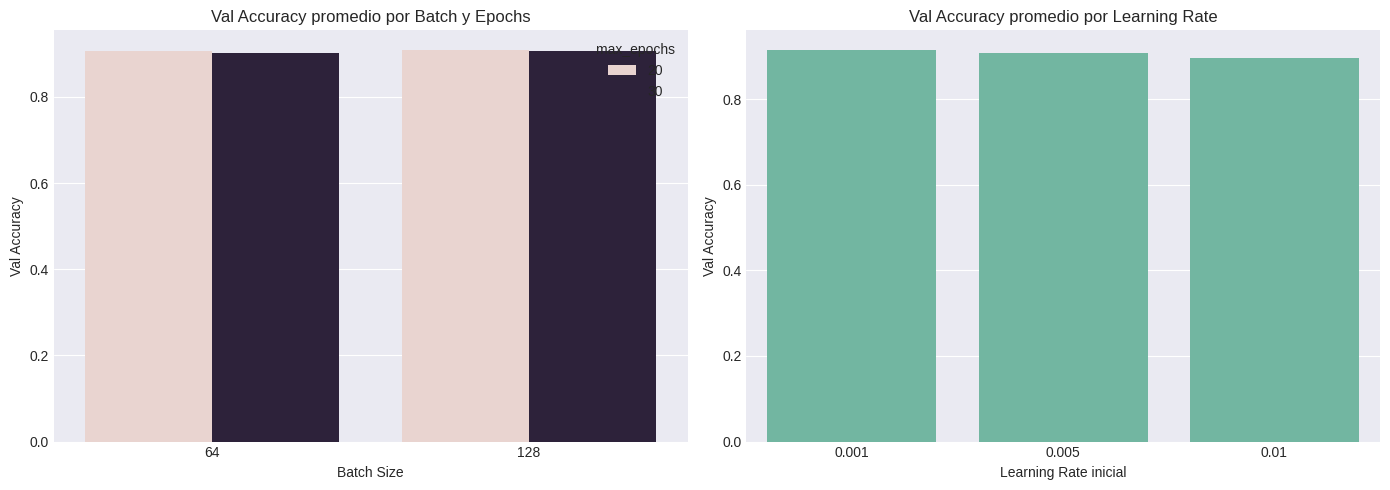

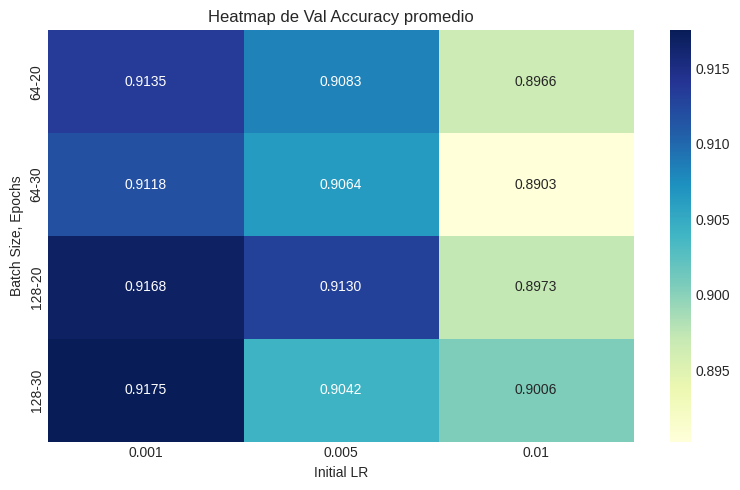

In [17]:
# Visualizaciones de apoyo para el analisis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=results_df, x='batch_size', y='val_accuracy', hue='max_epochs',
    errorbar=None, estimator=np.mean, ax=axes[0]
 )
axes[0].set_title('Val Accuracy promedio por Batch y Epochs')
axes[0].set_xlabel('Batch Size')
axes[0].set_ylabel('Val Accuracy')

sns.barplot(
    data=results_df, x='initial_lr', y='val_accuracy',
    errorbar=None, estimator=np.mean, ax=axes[1]
 )
axes[1].set_title('Val Accuracy promedio por Learning Rate')
axes[1].set_xlabel('Learning Rate inicial')
axes[1].set_ylabel('Val Accuracy')

plt.tight_layout()
plt.show()

pivot_acc = results_df.pivot_table(
    values='val_accuracy',
    index=['batch_size', 'max_epochs'],
    columns='initial_lr',
    aggfunc='mean'
 )

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_acc, annot=True, fmt='.4f', cmap='YlGnBu')
plt.title('Heatmap de Val Accuracy promedio')
plt.ylabel('Batch Size, Epochs')
plt.xlabel('Initial LR')
plt.tight_layout()
plt.show()

In [18]:
# Pregunta A
print('A. Cual tasa de aprendizaje funciono mejor y por que?\n')

lr_summary = (
    results_df.groupby('initial_lr', as_index=False)
    .agg(
        val_accuracy_prom=('val_accuracy', 'mean'),
        val_loss_prom=('val_loss', 'mean'),
        veces_reduce_lr=('lr_reduced', 'sum'),
        veces_early_stop=('early_stopped', 'sum')
    )
    .sort_values('val_accuracy_prom', ascending=False)
 )

display(lr_summary)

best_lr_row = lr_summary.iloc[0]
print(
    f"La mejor LR promedio fue {best_lr_row['initial_lr']:.3f}, "
    f"porque obtuvo mayor val_accuracy promedio ({best_lr_row['val_accuracy_prom']:.4f}) "
    f"y val_loss promedio de {best_lr_row['val_loss_prom']:.4f}."
 )

A. Cual tasa de aprendizaje funciono mejor y por que?



,initial_lr,val_accuracy_prom,val_loss_prom,veces_reduce_lr,veces_early_stop
0,0.001,0.914900,0.236469,4,3
1,0.005,0.907975,0.274100,4,4
2,0.010,0.896200,0.305571,4,3


La mejor LR promedio fue 0.001, porque obtuvo mayor val_accuracy promedio (0.9149) y val_loss promedio de 0.2365.


In [19]:
# Pregunta B
print('B. Que combinaciones de epochs y batch size dieron mejores resultados de val_accuracy?\n')

combo_summary = (
    results_df.groupby(['batch_size', 'max_epochs'], as_index=False)
    .agg(
        val_accuracy_prom=('val_accuracy', 'mean'),
        val_loss_prom=('val_loss', 'mean')
    )
    .sort_values('val_accuracy_prom', ascending=False)
 )

display(combo_summary)

best_combo = combo_summary.iloc[0]
print(
    f"La combinacion mas consistente fue Batch={int(best_combo['batch_size'])}, "
    f"Epochs={int(best_combo['max_epochs'])} "
    f"con val_accuracy promedio={best_combo['val_accuracy_prom']:.4f}."
 )

B. Que combinaciones de epochs y batch size dieron mejores resultados de val_accuracy?



,batch_size,max_epochs,val_accuracy_prom,val_loss_prom
2,128,20,0.909033,0.269237
3,128,30,0.907433,0.259678
0,64,20,0.906133,0.277999
1,64,30,0.902833,0.281273


La combinacion mas consistente fue Batch=128, Epochs=20 con val_accuracy promedio=0.9090.


In [20]:
# Pregunta C
print('C. Cuando se activo mas ReduceLROnPlateau segun hiperparametros iniciales?\n')

reduce_by_triplet = (
    results_df.groupby(['initial_lr', 'batch_size', 'max_epochs'], as_index=False)
    .agg(activaciones_reduce_lr=('lr_reduced', 'sum'))
    .sort_values('activaciones_reduce_lr', ascending=False)
 )

reduce_by_lr = (
    results_df.groupby('initial_lr', as_index=False)
    .agg(total_activaciones=('lr_reduced', 'sum'))
    .sort_values('total_activaciones', ascending=False)
 )

display(reduce_by_triplet)
display(reduce_by_lr)

top_reduce = reduce_by_triplet.iloc[0]
print(
    'Mayor activacion de ReduceLROnPlateau en combinacion: '
    f"LR={top_reduce['initial_lr']:.3f}, Batch={int(top_reduce['batch_size'])}, "
    f"Epochs={int(top_reduce['max_epochs'])}."
 )

C. Cuando se activo mas ReduceLROnPlateau segun hiperparametros iniciales?



,initial_lr,batch_size,max_epochs,activaciones_reduce_lr
0,0.001,64,20,1
1,0.001,64,30,1
2,0.001,128,20,1
3,0.001,128,30,1
4,0.005,64,20,1
5,0.005,64,30,1
6,0.005,128,20,1
7,0.005,128,30,1
8,0.010,64,20,1
9,0.010,64,30,1


,initial_lr,total_activaciones
0,0.001,4
1,0.005,4
2,0.010,4


Mayor activacion de ReduceLROnPlateau en combinacion: LR=0.001, Batch=64, Epochs=20.


In [21]:
# Pregunta D
print('D. Cuando se activo mas EarlyStopping segun hiperparametros iniciales?\n')

early_by_triplet = (
    results_df.groupby(['initial_lr', 'batch_size', 'max_epochs'], as_index=False)
    .agg(activaciones_early_stop=('early_stopped', 'sum'))
    .sort_values('activaciones_early_stop', ascending=False)
 )

early_by_lr = (
    results_df.groupby('initial_lr', as_index=False)
    .agg(total_activaciones=('early_stopped', 'sum'))
    .sort_values('total_activaciones', ascending=False)
 )

display(early_by_triplet)
display(early_by_lr)

top_early = early_by_triplet.iloc[0]
print(
    'Mayor activacion de EarlyStopping en combinacion: '
    f"LR={top_early['initial_lr']:.3f}, Batch={int(top_early['batch_size'])}, "
    f"Epochs={int(top_early['max_epochs'])}."
 )

D. Cuando se activo mas EarlyStopping segun hiperparametros iniciales?



,initial_lr,batch_size,max_epochs,activaciones_early_stop
0,0.001,64,20,1
1,0.001,64,30,1
3,0.001,128,30,1
4,0.005,64,20,1
9,0.010,64,30,1
5,0.005,64,30,1
6,0.005,128,20,1
7,0.005,128,30,1
11,0.010,128,30,1
10,0.010,128,20,1


,initial_lr,total_activaciones
1,0.005,4
0,0.001,3
2,0.010,3


Mayor activacion de EarlyStopping en combinacion: LR=0.001, Batch=64, Epochs=20.


In [22]:
# Pregunta E
print('E. Cual combinacion dio mejor entrenamiento y mejor validacion (pueden ser distintas)?\n')

best_train = results_df.loc[results_df['train_accuracy'].idxmax()]
best_val = results_df.loc[results_df['val_accuracy'].idxmax()]

resumen_E = pd.DataFrame([
    {
        'criterio': 'Mejor entrenamiento (max train_accuracy)',
        'experiment_id': int(best_train['experiment_id']),
        'initial_lr': float(best_train['initial_lr']),
        'batch_size': int(best_train['batch_size']),
        'max_epochs': int(best_train['max_epochs']),
        'real_epochs': int(best_train['real_epochs']),
        'train_accuracy': float(best_train['train_accuracy']),
        'val_accuracy': float(best_train['val_accuracy']),
        'train_loss': float(best_train['train_loss']),
        'val_loss': float(best_train['val_loss'])
    },
    {
        'criterio': 'Mejor validacion (max val_accuracy)',
        'experiment_id': int(best_val['experiment_id']),
        'initial_lr': float(best_val['initial_lr']),
        'batch_size': int(best_val['batch_size']),
        'max_epochs': int(best_val['max_epochs']),
        'real_epochs': int(best_val['real_epochs']),
        'train_accuracy': float(best_val['train_accuracy']),
        'val_accuracy': float(best_val['val_accuracy']),
        'train_loss': float(best_val['train_loss']),
        'val_loss': float(best_val['val_loss'])
    }
])

display(resumen_E)

print('Observacion: si las filas son distintas, el mejor ajuste en entrenamiento no coincide con el mejor en validacion.')

E. Cual combinacion dio mejor entrenamiento y mejor validacion (pueden ser distintas)?



,criterio,experiment_id,initial_lr,batch_size,max_epochs,real_epochs,train_accuracy,val_accuracy,train_loss,val_loss
0,Mejor entrenamiento (max train_accuracy),7,0.005,128,20,18,0.95534,0.9130,0.114715,0.270361
1,Mejor validacion (max val_accuracy),4,0.001,128,30,23,0.95264,0.9175,0.127269,0.234663


Observacion: si las filas son distintas, el mejor ajuste en entrenamiento no coincide con el mejor en validacion.
